Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/sentiment.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 6.36MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trades.csv
100%|██████████| 47.5M/47.5M [00:01<00:00, 43.2MB/s]



=== DATASET INFO ===
Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates (Sentiment): 0
Duplicates (Trades): 0

Sample Sentiment Dates: [datetime.date(2018, 2, 1) datetime.date(2018, 2, 2)
 datetime.date(2018, 2, 3) datetime.date(2018, 2, 4)
 datetime.date(2018, 2, 5)]
Sample Trade Dates: [datetime.date(2024, 2, 12) datetime.date(2024, 3, 12)
 datetime.date(2024, 4, 12) datetime.date(2025, 4, 3)
 datetime.date(2025, 5, 3)]

Final merged shape: (530, 8)

=== PERFORMA

<Figure size 640x480 with 0 Axes>

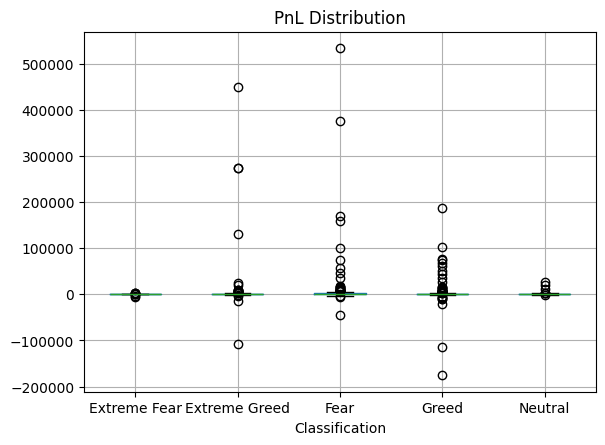

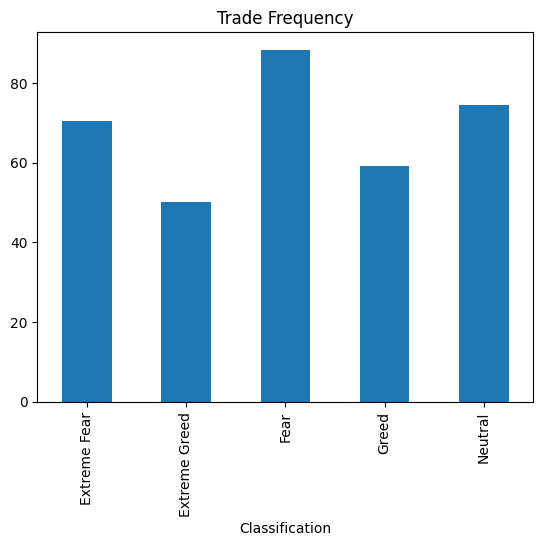


Model Accuracy: 0.9150943396226415

✅ ALL TASKS COMPLETED SUCCESSFULLY!


In [8]:
# ============================================
# FINAL COMPLETE PROJECT CODE (ALL TASKS)
# ============================================

!pip install gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ============================================
# 1. DOWNLOAD DATA
# ============================================

gdown.download("https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf", "sentiment.csv", quiet=False)
gdown.download("https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs", "trades.csv", quiet=False)

# ============================================
# 2. LOAD DATA
# ============================================

sentiment = pd.read_csv("sentiment.csv")
trades = pd.read_csv("trades.csv")

# ============================================
# PART A — DATA PREPARATION
# ============================================

print("\n=== DATASET INFO ===")
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values (Sentiment):\n", sentiment.isnull().sum())
print("\nMissing values (Trades):\n", trades.isnull().sum())

print("\nDuplicates (Sentiment):", sentiment.duplicated().sum())
print("Duplicates (Trades):", trades.duplicated().sum())

# ============================================
#  FIX TIMESTAMP (CRITICAL)
# ============================================

# Detect if timestamp is in ms or s
if sentiment['timestamp'].astype(str).str.len().iloc[0] > 10:
    sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='ms', errors='coerce')
else:
    sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s', errors='coerce')

# Convert trades timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

# Extract DATE ONLY
sentiment['date'] = sentiment['timestamp'].dt.date
trades['date'] = trades['Timestamp IST'].dt.date

print("\nSample Sentiment Dates:", sentiment['date'].dropna().unique()[:5])
print("Sample Trade Dates:", trades['date'].dropna().unique()[:5])

# ============================================
# CLEAN DATA
# ============================================

sentiment = sentiment.dropna(subset=['date', 'classification'])
trades = trades.dropna(subset=['date', 'Account', 'Closed PnL'])

# ============================================
# FEATURE ENGINEERING
# ============================================

# Daily PnL
daily_metrics = trades.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Size Tokens': 'mean'
}).reset_index()

daily_metrics.rename(columns={
    'Account': 'account',
    'Closed PnL': 'closedPnL',
    'Size Tokens': 'size'
}, inplace=True)

# Trades per day
daily_metrics['num_trades'] = trades.groupby(['Account', 'date']).size().values

# Win rate
trades['win'] = trades['Closed PnL'] > 0
win_rate = trades.groupby(['Account', 'date'])['win'].mean().reset_index()
win_rate.columns = ['account', 'date', 'win_rate']

daily_metrics = daily_metrics.merge(win_rate, on=['account', 'date'])

# Long/Short ratio
long_short = trades.groupby(['date', 'Side']).size().unstack(fill_value=0)

if 'BUY' in long_short.columns and 'SELL' in long_short.columns:
    long_short['long_short_ratio'] = long_short['BUY'] / (long_short['SELL'] + 1)
else:
    long_short['long_short_ratio'] = 1

long_short = long_short.reset_index()
daily_metrics = daily_metrics.merge(long_short[['date', 'long_short_ratio']], on='date', how='left')

# ============================================
# MERGE DATASETS
# ============================================

final_df = daily_metrics.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

final_df.rename(columns={'classification': 'Classification'}, inplace=True)

print("\nFinal merged shape:", final_df.shape)

# ============================================
# PART B — ANALYSIS
# ============================================

print("\n=== PERFORMANCE BY SENTIMENT ===")
print(final_df.groupby('Classification')[['closedPnL','win_rate','num_trades']].mean())

# Segmentation
final_df['leverage_group'] = 'Unknown'  # no leverage data
median_trades = final_df['num_trades'].median()

final_df['frequency_group'] = final_df['num_trades'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

# ============================================
# VISUALIZATION
# ============================================

plt.figure()
final_df.boxplot(column='closedPnL', by='Classification')
plt.title("PnL Distribution")
plt.suptitle("")
plt.show()

plt.figure()
final_df.groupby('Classification')['num_trades'].mean().plot(kind='bar')
plt.title("Trade Frequency")
plt.show()

# ============================================
# PART C — ML MODEL
# ============================================

final_df['profit_label'] = (final_df['closedPnL'] > 0).astype(int)

X = final_df[['num_trades', 'size', 'win_rate']].fillna(0)
y = final_df['profit_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

print("\n ALL TASKS COMPLETED")